# Solver comparison

## Imports

In [6]:
import sys
import os

root = os.path.dirname(os.getcwd())
sys.path.append(root)

import time
import math
import numpy as np
import matplotlib.pyplot as plt

from cvrptw.parser import parse_solomon
from cvrptw.model import Instance
from cvrptw.solvers.gurobi_solver import solve as gurobi_solve
from cvrptw.heuristics.alns import solve as alns_solve
from cvrptw.solvers.ortools_solver import solve as ortools_solve


## Configuration

unseen instances and seeds to avoid seeing a good alns model associated to overfitting t the same instances (not probably in this case but still good practice)

In [7]:
UNSEEN_INSTANCES = {
    'c102': '../data/solomon/c102.txt',
    'r102': '../data/solomon/r102.txt',
    'rc102': '../data/solomon/rc102.txt',
    'r202': '../data/solomon/r202.txt',
    'rc202': '../data/solomon/rc202.txt',
}
BEST_KNOWN = {
    'c102': 828.94,
    'r102': 1486.12,
    'rc102': 1554.75,
    'r202': 1191.70,
    'rc202': 1365.65,
}
UNSEEN_SEEDS = [5, 6, 7]

GUROBI_NAME = 'c102'

BEST_KNOWN_VEHICLES = {
    'c102': 10,
    'r102': 17,
    'rc102': 12,
    'r202': 3,
    'rc202': 3,
}


## Gurobi on a small subinstance to compare with alns model


In [8]:
gurobi_full = parse_solomon(UNSEEN_INSTANCES[GUROBI_NAME])
gurobi_instance = Instance(gurobi_full.name, gurobi_full.vehicle_capacity,
                           gurobi_full.nodes[:21], gurobi_full.num_vehicles)

start = time.perf_counter()
gurobi_solution = gurobi_solve(gurobi_instance)
gurobi_time = time.perf_counter() - start
gurobi_optimum = gurobi_solution.distance()

alns_sub, _ = alns_solve(gurobi_instance, seed=5, n=10)
ortools_sub = ortools_solve(gurobi_instance, time_limit=1)

print(f'gurobi  optimum={gurobi_optimum:.1f} in {gurobi_time:.1f}s feasible={gurobi_solution.is_feasible()}')
print(f'alns    ={alns_sub.distance():.1f} gap={(alns_sub.distance() - gurobi_optimum) / gurobi_optimum * 100:+.2f}%')
print(f'ortools ={ortools_sub.distance():.1f} gap={(ortools_sub.distance() - gurobi_optimum) / gurobi_optimum * 100:+.2f}%')


gurobi  optimum=167.2 in 0.7s feasible=True
alns    =167.2 gap=+0.00%
ortools =167.2 gap=+0.00%


we can see how in a small dataset both ortools and our alns model reach the optimum in 0.0 seconds while an exact aproach to the problem (with gurobit) takes half a second, this time scales really fast as seen in the gurobi_scaling notebook and it takes too long to run in a 100 node full instance

## My alns code vs or-tools

or-tools runs with the alns runtime as its time limit to just compare the solution gap (simple aproach)

In [9]:
records = []
for name, path in UNSEEN_INSTANCES.items():
    instance = parse_solomon(path)
    ref = BEST_KNOWN[name]
    for seed in UNSEEN_SEEDS:
        start = time.perf_counter()
        alns_solution, _ = alns_solve(instance, seed=seed)
        alns_time = time.perf_counter() - start
        ortools_solution = ortools_solve(instance, time_limit=max(1, math.ceil(alns_time)))
        records.append({
            'instance': name,
            'seed': seed,
            'alns_gap': (alns_solution.distance() - ref) / ref * 100,
            'ortools_gap': (ortools_solution.distance() - ref) / ref * 100,
            'alns_time': alns_time,
            'alns_vehicles': alns_solution.num_vehicles,
            'ortools_vehicles': ortools_solution.num_vehicles,
        })
        print(f'{name} seed={seed} alns_gap={records[-1]["alns_gap"]:+.2f}% '
              f'ortools_gap={records[-1]["ortools_gap"]:+.2f}% alns_time={alns_time:.1f}s')


c102 seed=5 alns_gap=-0.00% ortools_gap=-0.00% alns_time=4.6s
c102 seed=6 alns_gap=-0.00% ortools_gap=-0.00% alns_time=5.2s
c102 seed=7 alns_gap=-0.00% ortools_gap=-0.00% alns_time=2.3s
r102 seed=5 alns_gap=+2.85% ortools_gap=+0.04% alns_time=2.5s
r102 seed=6 alns_gap=+1.02% ortools_gap=+0.04% alns_time=3.1s
r102 seed=7 alns_gap=+1.92% ortools_gap=+0.04% alns_time=3.1s
rc102 seed=5 alns_gap=-1.80% ortools_gap=+0.78% alns_time=1.6s
rc102 seed=6 alns_gap=-4.18% ortools_gap=-2.27% alns_time=3.8s
rc102 seed=7 alns_gap=-0.31% ortools_gap=+0.77% alns_time=1.5s
r202 seed=5 alns_gap=-8.57% ortools_gap=-3.39% alns_time=2.3s
r202 seed=6 alns_gap=-8.97% ortools_gap=-3.39% alns_time=2.7s
r202 seed=7 alns_gap=-9.65% ortools_gap=-3.39% alns_time=2.4s
rc202 seed=5 alns_gap=-12.34% ortools_gap=-13.15% alns_time=4.3s
rc202 seed=6 alns_gap=-13.83% ortools_gap=-13.18% alns_time=5.2s
rc202 seed=7 alns_gap=-14.24% ortools_gap=-11.96% alns_time=2.1s


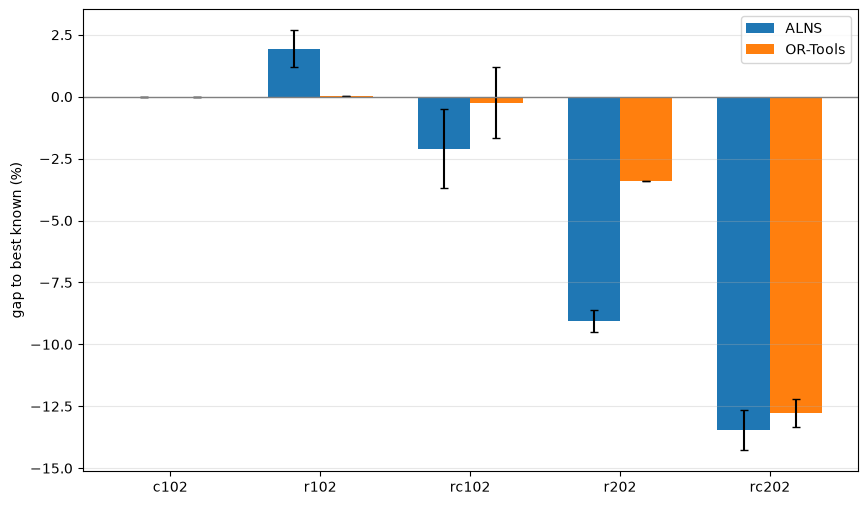

In [14]:
names = list(UNSEEN_INSTANCES)
x = np.arange(len(names))
width = 0.35

alns_means = [np.mean([r['alns_gap'] for r in records if r['instance'] == name]) for name in names]
alns_stds = [np.std([r['alns_gap'] for r in records if r['instance'] == name]) for name in names]
ortools_means = [np.mean([r['ortools_gap'] for r in records if r['instance'] == name]) for name in names]
ortools_stds = [np.std([r['ortools_gap'] for r in records if r['instance'] == name]) for name in names]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, alns_means, width, yerr=alns_stds, capsize=3, label='ALNS')
ax.bar(x + width / 2, ortools_means, width, yerr=ortools_stds, capsize=3, label='OR-Tools')
ax.axhline(0, color='gray', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('gap to best known (%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.show()


We can see how by using the same time for both solvers our alns solver matches the gap and on most instances slightly lower gaps to the real solution (with or-tools being better on the r1 instance). We ha ve to keep in mind that the gap being negative is due to the optimal solution we are using to compare being build by first minimizing number of vans and then minimizing distance, but since both the or-tools solver and our alns metaheuristic only minimize distance the comparison is fair. It is also important to keep in mind that the ortools solver is an industry level solver but wasnt build specially for this problem but being able to match and even beat it on some instances, with a metaheuristic we built from scratch and under the same time budget, is a strong result for our solver. We should also note that a more negative gap means a shorter distance but it may use more vehicles so without comparing the number of vehicles it is not strictly a better solution and that or-tools would likely improve if given more time than our alns runtime.

## Vehicle number analysis

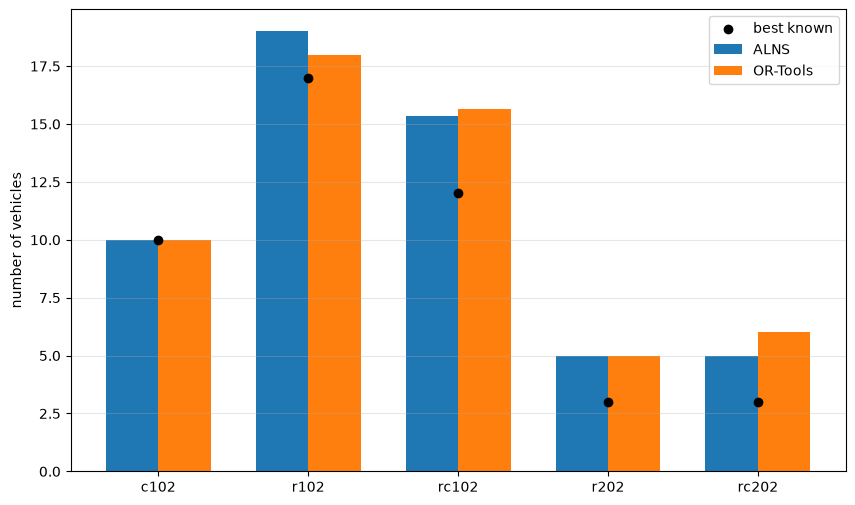

In [15]:
names = list(UNSEEN_INSTANCES)
x = np.arange(len(names))
width = 0.35

alns_vehicles = [np.mean([r['alns_vehicles'] for r in records if r['instance'] == name]) for name in names]
ortools_vehicles = [np.mean([r['ortools_vehicles'] for r in records if r['instance'] == name]) for name in names]
bks_vehicles = [BEST_KNOWN_VEHICLES[name] for name in names]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, alns_vehicles, width, label='ALNS')
ax.bar(x + width / 2, ortools_vehicles, width, label='OR-Tools')
ax.scatter(x, bks_vehicles, color='black', zorder=5, label='best known')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('number of vehicles')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.show()


By seeing this last graph we can see how negative distance aligns with using more vehicles than the benchmark solution, this allows us to also compare our solver to the or-tools aproach, where we can see how the or-tools aproach has a similar number of vans to our metaheuristic and this is probably due to the limited time allowed where or-tools would likely improve if given more time than our alns runtime. With all the analysis we can see how our code can match the or-tools solver in this particular prolem proving to be a great aproach to the problem.